In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils.common import extract_latents_with_names, combine_audio_and_lyrics
from run_models import run_VAE, run_KMeans, run_Agglomerative, run_DBSCAN

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, numpy as np
from pathlib import Path

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
root = Path("../..")

### check that config.VAE_TYPE = "conv" and config.MODEL_TYPE = "cvae"

In [6]:
config.VAE_TYPE, config.MODEL_TYPE

('conv', 'cvae')

In [7]:
cvae, latent_dim, train_loader, test_loader, vae_history, study = run_VAE(model_type="cvae", root=root, plot_dir_name="hard_2_cvae_audio_lyrics")

d:\MSc\3. Spring 2026\CSE715\Project\vae-audio-clustering\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-04-10 08:55:12,326] A new study created in memory with name: Conditional VAE Tuning
  0%|          | 0/5 [00:00<?, ?it/s]

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 408.8207     | 246.2523    
Recon        | 363.6016     | 241.0332    
KL Div       | 226.0956     | 26.0954     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 354.3245     | 235.9364    
Recon        | 307.5333     | 224.5126    
KL Div       | 233.9561     | 57.1189     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 207.5974     | 155.6714    
Recon        | 193.7783     | 146.5222    
KL Div       | 69.0953      | 45.7459     
--------------------------------------

  0%|          | 0/5 [00:06<?, ?it/s]

--------------------------------------------------
Epoch 5 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 109.8634     | 100.2135    
Recon        | 99.8722      | 91.3475     
KL Div       | 49.9559      | 44.3301     
--------------------------------------------------

[I 2026-04-10 08:55:19,177] Trial 0 finished with value: 72.54051445715206 and parameters: {'CHANNEL_1': 4, 'CHANNEL_2_MULTIPLIER': 8, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 16, 'LR': 0.0001519934830130982, 'BATCH_SIZE': 64, 'BETA': 3.0}. Best is trial 0 with value: 72.54051445715206.


Best trial: 0. Best value: 72.5405:  20%|██        | 1/5 [00:07<00:28,  7.02s/it]

...

--------------------------------------------------
Epoch 1 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 188.0348     | 92.1798     
Recon        | 173.7534     | 80.9730     
KL Div       | 71.4069      | 56.0337     
--------------------------------------------------

--------------------------------------------------
Epoch 2 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 85.7672      | 74.4859     
Recon        | 75.5273      | 63.5821     
KL Div       | 51.1997      | 54.5187     
--------------------------------------------------

--------------------------------------------------
Epoch 3 / 5
Metric       | Train        | Test        
--------------------------------------------------
Total Loss   | 72.8253      | 65.2750     
Recon        | 63.1705      | 55.7728     
KL Div       | 48.2743      | 47.5107     
--------------------------------------

Best trial: 1. Best value: 69.8665:  80%|████████  | 4/5 [01:24<00:17, 17.64s/it]

[I 2026-04-10 08:56:36,518] Trial 4 finished with value: 46.585244310516664 and parameters: {'CHANNEL_1': 8, 'CHANNEL_2_MULTIPLIER': 2, 'CHANNEL_3_MULTIPLIER': 4, 'LATENT_DIM': 32, 'LR': 0.0002572663133249957, 'BATCH_SIZE': 16, 'BETA': 3.0}. Best is trial 4 with value: 46.585244310516664.


Best trial: 4. Best value: 46.5852: 100%|██████████| 5/5 [01:24<00:00, 16.88s/it]


..\..\results\trials\hard_2_cvae_audio_lyrics\plots
Saved: ..\..\results\trials\hard_2_cvae_audio_lyrics\plots\optimization_history.html
Saved: ..\..\results\trials\hard_2_cvae_audio_lyrics\plots\param_importances.html
Saved: ..\..\results\trials\hard_2_cvae_audio_lyrics\plots\parallel_coordinate.html
Saved: ..\..\results\trials\hard_2_cvae_audio_lyrics\plots\edf.html
Saved: ..\..\results\trials\hard_2_cvae_audio_lyrics\plots\timeline.html
Saved: ..\..\results\trials\hard_2_cvae_audio_lyrics\plots\contour.html
Best trial for `cvae`:
Score: 46.5852
    CHANNEL_1                 8
    CHANNEL_2_MULTIPLIER      2
    CHANNEL_3_MULTIPLIER      4
    LATENT_DIM                32
    LR                        0.0002572663133249957
    BATCH_SIZE                16
    BETA                      3.0


FINAL MODEL:
 VAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affi

In [8]:
train_latents, train_labels, train_audio_names = extract_latents_with_names(model=cvae, loader=train_loader, device=device)
test_latents, test_labels, test_audio_names  = extract_latents_with_names(model=cvae, loader=test_loader,  device=device)

In [9]:
vae_latents = np.concatenate([train_latents, test_latents], axis=0)
vae_labels = np.concatenate([train_labels,  test_labels],  axis=0)
vae_audio_names = np.concatenate([train_audio_names, test_audio_names], axis=0)

In [10]:
latent_vecs_hybrid = combine_audio_and_lyrics(latent_vecs=vae_latents, audio_names=vae_audio_names, root=root)




Optimal k        : 5
Inertia (WCSS)   : 33058.7656
Silhouette Score : 0.2025
CH Index         : 526.1652
DB Index         : 1.5524
ARI              : 0.0560
NMI              : 0.0745
Purity           : 0.3717



n_clusters not provided for Agglomerative — running elbow method to determine k...



Agglomerative  n_clusters=5  linkage='ward'
Silhouette Score : 0.1630
CH Index         : 447.4592
DB Index         : 1.5684
ARI              : 0.0374
NMI              : 0.0572
Purity           : 0.3502






DBSCAN  eps=2.5  min_samples=5
Clusters found   : 4
Noise points     : 796



DB-SCAN
Silhouette Score : 0.0591
CH Index         : 131.0003
DB Index         : 1.7611
ARI              : 0.0001
NMI              : 0.0163
Purity           : 0.3329





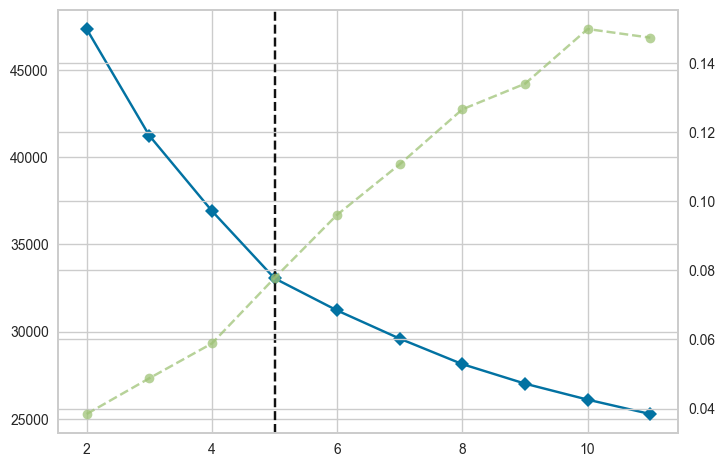

In [11]:
vae_kmeans, vae_kmeans_metrics = run_KMeans(vae_latents, model_type="hard_2_cvae_audio_lyrics", true_labels=vae_labels, root=root)
vae_agglomerative, vae_agglomerative_metrics = run_Agglomerative(vae_latents, model_type="hard_2_cvae_audio_lyrics", true_labels=vae_labels, root=root)
vae_dbscan, vae_dbscan_metrics = run_DBSCAN(vae_latents, model_type="hard_2_cvae_audio_lyrics", true_labels=vae_labels, root=root)

In [12]:
from collections import Counter

for cluster_id in range(len(vae_kmeans.cluster_centers_)):
    mask = vae_kmeans.labels_ == cluster_id
    genre_counts = Counter(vae_labels[mask])
    print(f"Cluster {cluster_id}: {genre_counts}")

Cluster 0: Counter({np.int64(0): 269, np.int64(1): 264, np.int64(3): 106, np.int64(2): 89})
Cluster 1: Counter({np.int64(2): 266, np.int64(3): 234, np.int64(0): 178, np.int64(1): 108})
Cluster 2: Counter({np.int64(1): 54, np.int64(2): 52, np.int64(3): 51, np.int64(0): 47})
Cluster 3: Counter({np.int64(1): 173, np.int64(3): 101, np.int64(0): 66, np.int64(2): 64})
Cluster 4: Counter({np.int64(2): 139, np.int64(3): 114, np.int64(0): 47, np.int64(1): 2})


In [13]:
from visualizations import plot_tsne_clustering_comparison
from sklearn.metrics import silhouette_score

In [14]:
TSNE_DIR = root / config.TSNE_DIR
TSNE_DIR.mkdir(exist_ok=True, parents=True)

Computing t-SNE embeddings (this may take a minute)...
Saved → ..\..\results\clustering\tsne\hard_2_cvae_audio_lyrics


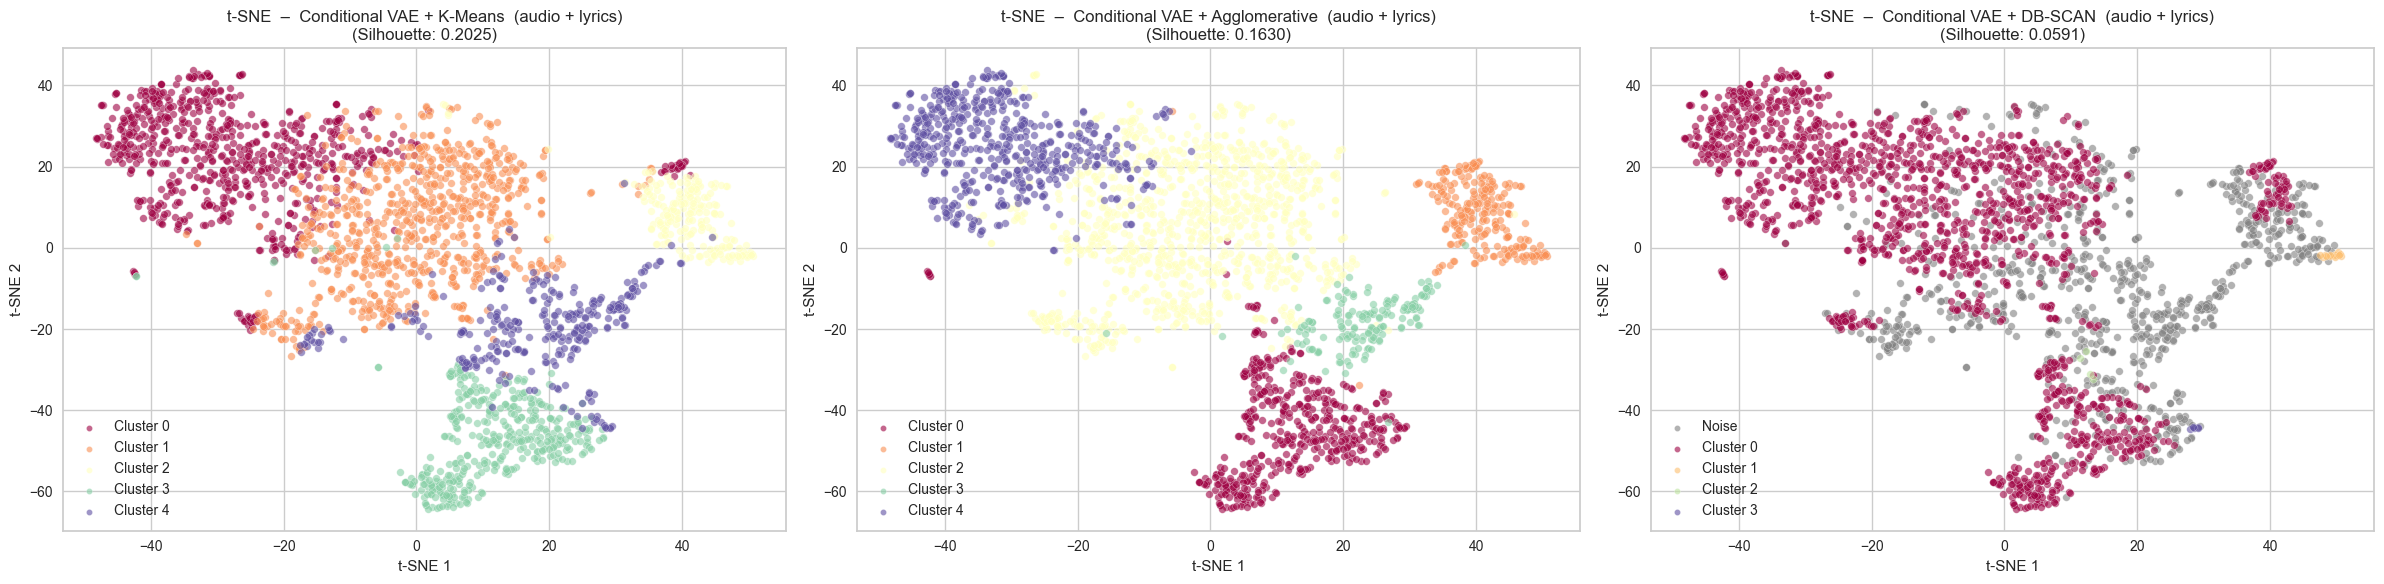

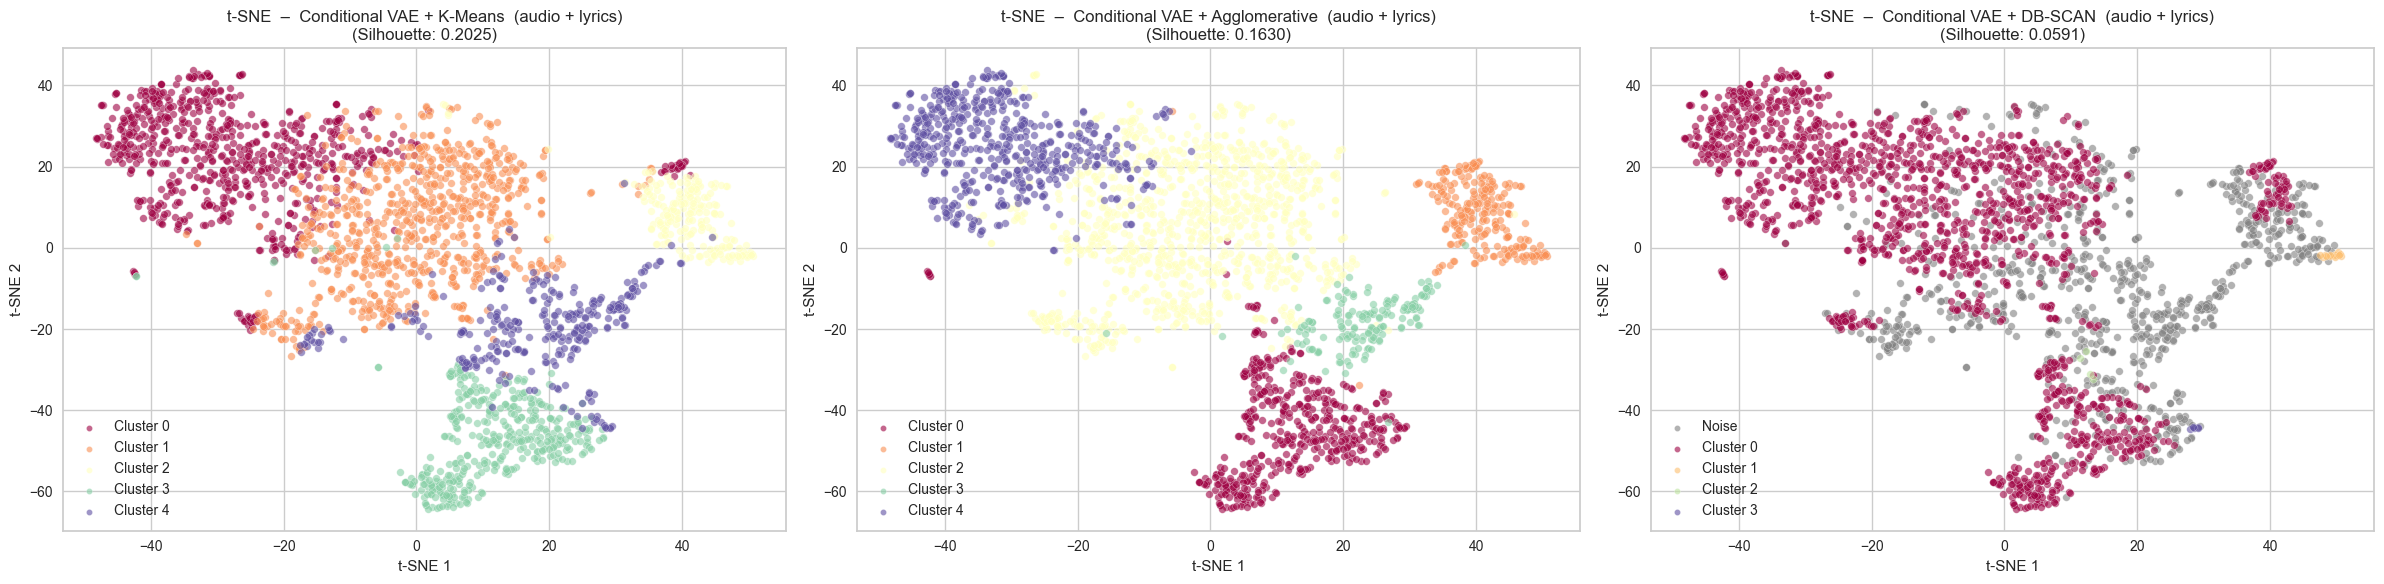

In [15]:
plot_tsne_clustering_comparison(
    vae_latents,
    [vae_kmeans.labels_, vae_agglomerative.labels_, vae_dbscan.labels_],
    ["Conditional VAE + K-Means  (audio + lyrics)", "Conditional VAE + Agglomerative  (audio + lyrics)", "Conditional VAE + DB-SCAN  (audio + lyrics)"],
    scores=[silhouette_score(vae_latents, vae_kmeans.labels_), silhouette_score(vae_latents, vae_agglomerative.labels_), silhouette_score(vae_latents, vae_dbscan.labels_)],
    save_path=TSNE_DIR / "hard_2_cvae_audio_lyrics"
)